# Loading Data

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.io as pio
pio.renderers.default = "kaggle"

df = pd.read_csv('/kaggle/input/car-price-prediction/CarPrice_Assignment.csv')
df.select_dtypes('object')

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo 246,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [2]:
df.drop(['car_ID'], axis=1, inplace=True)
df.isnull().sum().sort_values(ascending=False).head()

symboling     0
enginetype    0
highwaympg    0
citympg       0
peakrpm       0
dtype: int64

# Baseline model 

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

def baseline_model (X,y, model=RandomForestRegressor()):
    cat_cols = X.select_dtypes('object')
    for col in cat_cols.columns:
        X[col], label_values = X[col].factorize()
    
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=42)
    n_folds = 10
    models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor()),
    ("XGBoost", XGBRegressor())]
    for name, model in models:
        scores = cross_val_score(estimator=model, X=X_train, y=y_train, cv=n_folds, scoring="neg_mean_squared_log_error")
        rmsle_scores = np.sqrt(-1*scores)
        print(f"Mean RMSLE of {name}: {rmsle_scores.mean()}")


#================================================================
X = df.drop(['price'], axis=1)
y = df['price']

baseline_model(X,y)

Mean RMSLE of Linear Regression: 0.18750050631239995
Mean RMSLE of Random Forest: 0.15273631551717878
Mean RMSLE of XGBoost: 0.1625280136442162


# Pre-processing

In [4]:
print('number of car-name unique:', df['CarName'].str.split(' ', expand=True)[0].nunique())
print('unique car-names:\n', df['CarName'].str.split(' ', expand=True)[0].unique())

number of car-name unique: 28
unique car-names:
 ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan' 'nissan'
 'peugeot' 'plymouth' 'porsche' 'porcshce' 'renault' 'saab' 'subaru'
 'toyota' 'toyouta' 'vokswagen' 'volkswagen' 'vw' 'volvo']


In [5]:
# Create a new Feature named model, after dividing CarName features
df[['CarName', 'model']] = df['CarName'].str.split(' ', n=1, expand=True)

Car name columns has a wrong names of cars

In [6]:
# Re-write CarName of wrong values and transform all values to lower string
df['CarName'] = df['CarName'].replace({'porcshce':'porsche', 'toyouta':'toyota', 'vokswagen':'volkswagen', 'vw':'vokswagen', 'maxda':'mazda'})
df['CarName'] = df['CarName'].map(lambda x: x.lower())

In [7]:
# Check unique values of CarName after replace wrong values
df['CarName'].str.split(' ', expand=True)[0].nunique()

23

In [8]:
df.isnull().sum().sort_values(ascending=False).head()

model         2
CarName       0
price         0
highwaympg    0
citympg       0
dtype: int64

In [9]:
df[df['model'].isna()]

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,model
138,2,subaru,gas,std,two,hatchback,fwd,front,93.7,156.9,...,2bbl,3.62,2.36,9.0,69,4900,31,36,5118.0,None
141,0,subaru,gas,std,four,sedan,fwd,front,97.2,172.0,...,2bbl,3.62,2.64,9.5,82,4800,32,37,7126.0,None


In [10]:
df.fillna({'model':'subaru'}, inplace=True)
df.drop_duplicates(inplace=True)

In [11]:
df.select_dtypes('object')

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem,model
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi,giulia
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi,stelvio
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi,Quadrifoglio
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi,100 ls
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi,100ls
...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi,145e (sw)
201,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi,144ea
202,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi,244dl
203,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi,246


# EDA

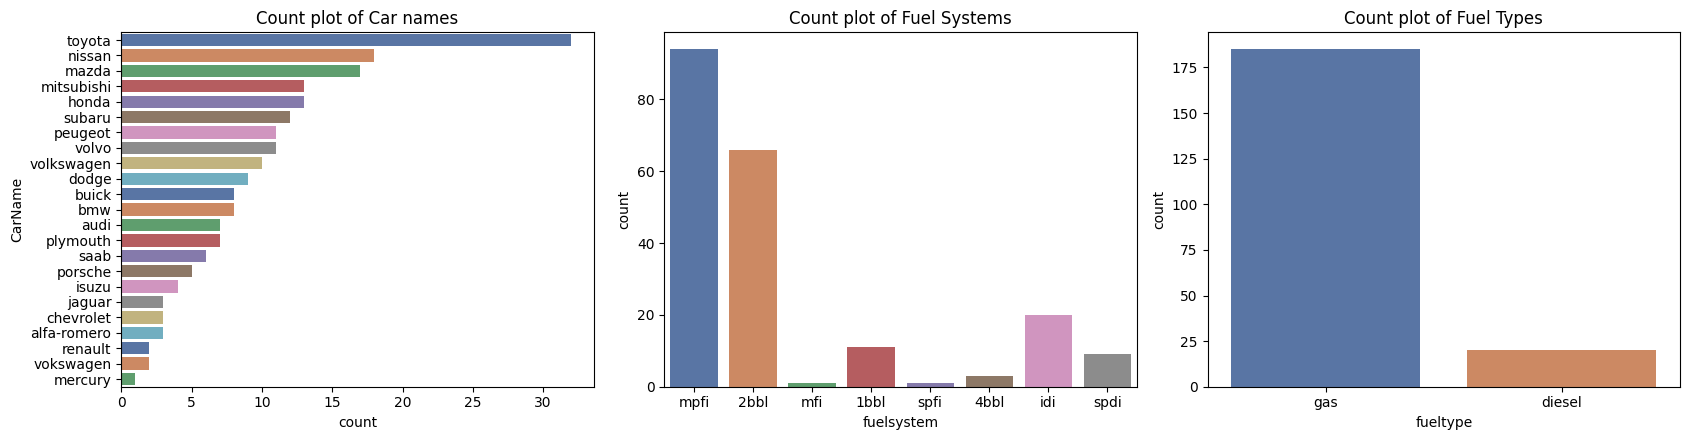

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1,3, figsize=(17, 4.5))

sns.countplot(df, y='CarName',ax=ax[0], palette='deep', order=df['CarName'].value_counts().index)
ax[0].set_title('Count plot of Car names')
sns.countplot(df, x='fuelsystem', ax=ax[1], palette='deep')
ax[1].set_title('Count plot of Fuel Systems')
sns.countplot(df, x='fueltype', ax=ax[2], palette='deep')
ax[2].set_title('Count plot of Fuel Types')

plt.tight_layout()
plt.show()

In [13]:
import plotly.express as px

X_new = df.groupby('CarName')['price'].mean()
X_new = pd.DataFrame(X_new.sort_values(ascending=True)).reset_index()

fig = px.bar(X_new, x='price', y='CarName')
fig.update_traces(marker_color='skyblue', textposition='outside')
#fig.show()
fig.show(renderer="iframe")

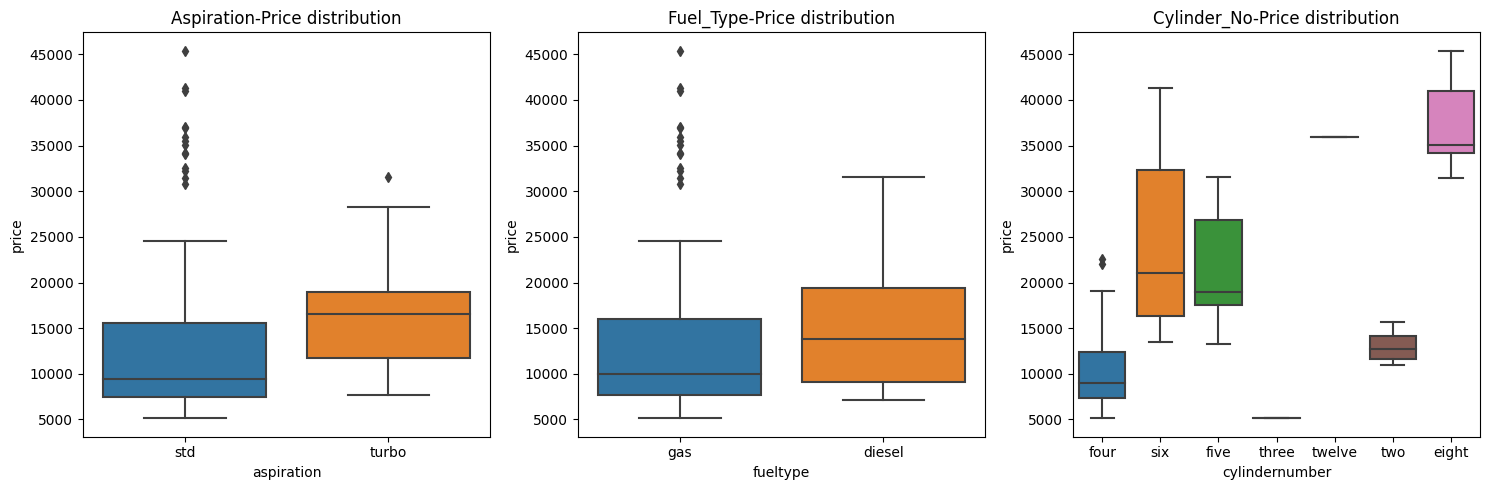

In [14]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
sns.boxplot(x='aspiration', y='price', data=df, ax=ax[0])
ax[0].set_title('Aspiration-Price distribution')
sns.boxplot(x='fueltype', y='price', data=df, ax=ax[1])
ax[1].set_title('Fuel_Type-Price distribution')
sns.boxplot(x='cylindernumber', y='price', data=df, ax=ax[2])
ax[2].set_title('Cylinder_No-Price distribution')

plt.tight_layout()
plt.show()

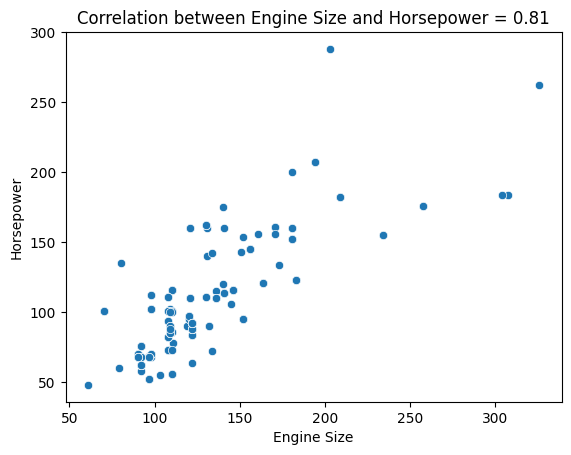

In [15]:
sns.scatterplot(x='enginesize', y='horsepower', data=df)
corr_value = df[['enginesize', 'horsepower']].corr().iloc[0,1]
plt.title(f'Correlation between Engine Size and Horsepower = {corr_value:.2f}')
plt.xlabel('Engine Size')
plt.ylabel('Horsepower')
plt.show()

In [16]:
df.columns

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'model'],
      dtype='object')

In [17]:
# Create a new features 
df["hp_rpm_ratio"] = df["horsepower"] / df["peakrpm"]
df["hp_rpm_ratio"].corr(df['price'])

0.8399531747509554

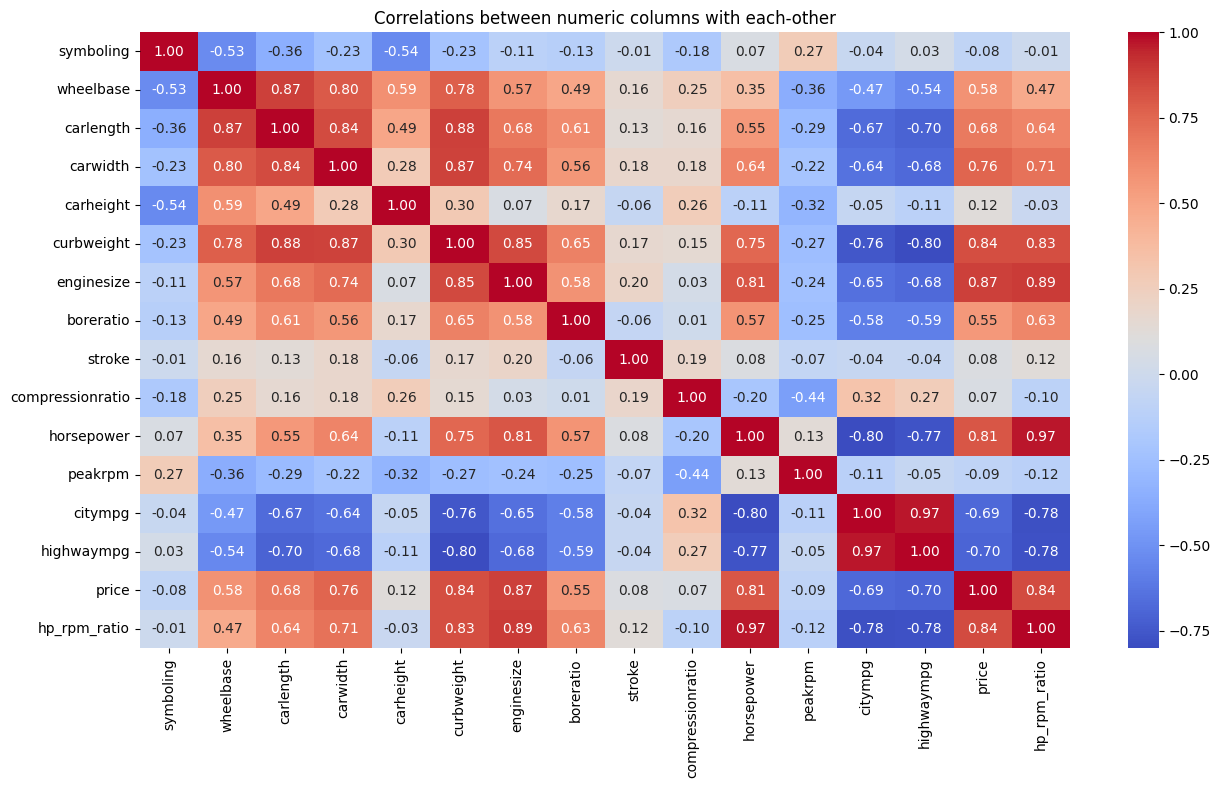

In [18]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlations between numeric columns with each-other')
plt.show()

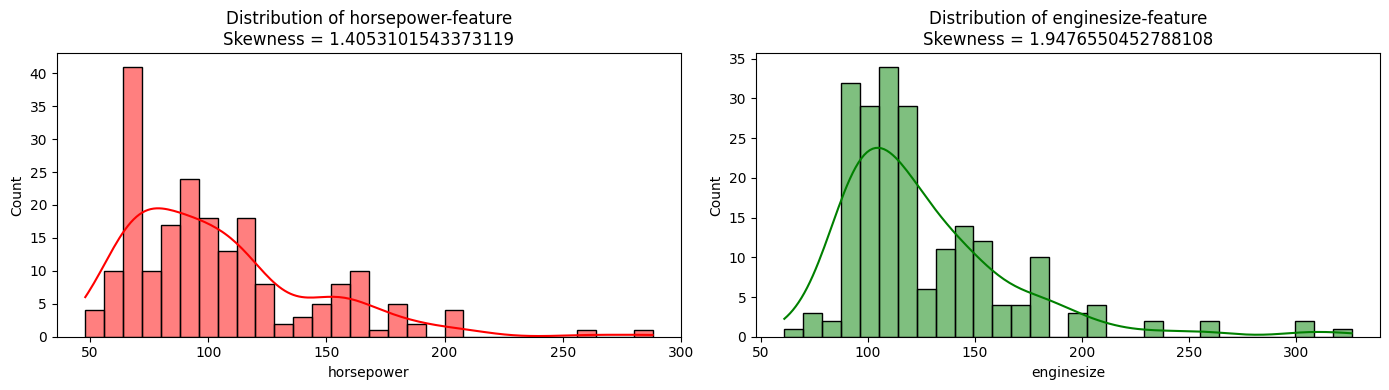

In [19]:
fig, ax = plt.subplots(1,2, figsize=(14, 4))

colors = ['red', 'green']
for i,col in enumerate(['horsepower', 'enginesize']):
    sns.histplot(df[col], color=colors[i], ax=ax[i], bins=30, kde=True)
    ax[i].set_title(f'Distribution of {col}-feature\nSkewness = {df[col].skew()}')


plt.tight_layout()
plt.show()

# Splitting data

In [20]:
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


X = df.copy()
y = X.pop('price')


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=42)

# Creating a new Features by grouping
FSCompR_mean = X_train.groupby('fuelsystem')['compressionratio'].mean()
FTCompR_mean = X_train.groupby('fueltype')['compressionratio'].mean()

X_train['FSCompR_mean'] = X_train['fuelsystem'].map(FSCompR_mean)
X_train['FTCompR_mean'] = X_train['fueltype'].map(FTCompR_mean)

X_test['FSCompR_mean']  = X_test['fuelsystem'].map(FSCompR_mean)
X_test['FTCompR_mean']  = X_test['fueltype'].map(FTCompR_mean)

global_mean  = X_train['compressionratio'].mean()
X_test[['FSCompR_mean', 'FTCompR_mean']] = X_test[['FSCompR_mean', 'FTCompR_mean']].fillna(global_mean)

In [21]:
from category_encoders import MEstimateEncoder

encoder = MEstimateEncoder(cols=['CarName'], m=5)
encoder.fit(X_train[['CarName']], y_train)

X_train['CN_Enc_Price'] = encoder.transform(X_train[['CarName']])
X_test['CN_Enc_Price']  = encoder.transform(X_test[['CarName']])

# Encoding label features

In [22]:
pip install word2number

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=213928798c3e999f65659bb2669d3a67c61ee36dcd90b5867beee8fec123e7e9
  Stored in directory: /root/.cache/pip/wheels/cd/ef/ae/073b491b14d25e2efafcffca9e16b2ee6d114ec5c643ba4f06
Successfully built word2number
Note: you may need to restart the kernel to use updated packages.


In [23]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from word2number import w2n

# Ordinal Encoding for Car-Name, drive-wheel, engine-type, fuel-system, and model
for col in ['CarName', 'drivewheel', 'enginetype', 'fuelsystem', 'model']:
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[col] = oe.fit_transform(X_train[[col]])
    X_test[col]  = oe.transform(X_test[[col]])

# Replace manually fuel-type, door-number, aspiration, and engine-location
for col in ['fueltype', 'doornumber', 'aspiration', 'enginelocation']:
    unique_values = X_train[col].unique()
    mapping = {unique_values[0]:0, unique_values[1]:1}
    X_train[col] = X_train[col].replace(mapping)
    X_test[col]  = X_test[col].replace(mapping)

# One-hot Encoding for Car-body
oh = OneHotEncoder(handle_unknown='ignore')
train_encoded_cols = oh.fit_transform(X_train[['carbody']]).toarray()
test_encoded_cols = oh.transform(X_test[['carbody']]).toarray()
for i,label in enumerate(oh.categories_[0]):
    X_train[label] = train_encoded_cols[:,i]
    X_test[label]  = test_encoded_cols[:,i]
    
X_train.drop(['carbody'], axis=1, inplace=True)
X_test.drop(['carbody'], axis=1, inplace=True)

# Word to number transformer
X_train.cylindernumber = X_train.cylindernumber.apply(w2n.word_to_num)
X_test.cylindernumber = X_test.cylindernumber.apply(w2n.word_to_num)

## Check MI

In [24]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X,y):
    mi_scores = mutual_info_regression(X,y)  
    mi_scores = pd.Series(mi_scores, name='MI_scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores 
    
mi_scores = make_mi_scores(X_train, y_train) 
mi_scores.head()

curbweight    0.934634
highwaympg    0.827245
citympg       0.811386
horsepower    0.803417
enginesize    0.790956
Name: MI_scores, dtype: float64

In [25]:
to_drop = list(mi_scores[mi_scores<=0.1].index)
X_train.drop(to_drop, axis=1, inplace=True)
X_test.drop(to_drop, axis=1, inplace=True)

In [26]:
import plotly.express as px

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    fig = px.bar(
        x=scores.values,
        y=scores.index,
        orientation='h',
        color=scores.values,                 
        color_continuous_scale='Reds',
        labels={'x':'MI Score', 'y':'Feature'},
        title='Mutual Information Score of each Feature'
    )
    fig.show()

plot_mi_scores(make_mi_scores(X_train, y_train))


# Model deployment

In [27]:
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor()),
    ("XGBoost", XGBRegressor())
]
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, scoring= 'neg_mean_squared_log_error', cv=10)
    rmsle_scores = np.sqrt(-1*scores)
    print(f"Mean RMSLE of {name}:", rmsle_scores.mean())

Mean RMSLE of Linear Regression: 0.16630269886758847
Mean RMSLE of Random Forest: 0.13806842690283144
Mean RMSLE of XGBoost: 0.14669975114972378


After feature engineering, scoring are improved.

Verify of this by looking at Random Forest score.

In [28]:
# Appling moodel on testing data

def test_score(X,y, name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X)
    score = mean_squared_log_error(y, y_pred)
    rmsle_score = np.sqrt(score)
    res_comp = pd.DataFrame()
    res_comp['Actual'], res_comp['Prediction'], res_comp['Diff'] = y, pd.Series(y_pred, index=y.index), abs(y - y_pred)

    
    return f"Mean RMSLE of {name}: {rmsle_score}", res_comp



best_rf = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
for i in range(2):
    if i==1:
        print(test_score(X_test, y_test, "Random Forest", best_rf)[i][::3])
    else:
         print(test_score(X_test, y_test, "Random Forest", best_rf)[i])

Mean RMSLE of Random Forest: 0.12034958276342042
      Actual    Prediction         Diff
15   30760.0  35498.027000  4738.027000
132  11850.0  13311.137365  1461.137365
159   7788.0   8031.026446   243.026446
182   7775.0   8303.073768   528.073768
65   18280.0  13155.353096  5124.646904
152   6488.0   6521.056987    33.056987
86    8189.0   8786.575756   597.575756
101  13499.0  14889.047216  1390.047216
25    6692.0   7347.523838   655.523838
195  13415.0  17056.503826  3641.503826
67   25552.0  29797.082000  4245.082000
202  21485.0  19008.399169  2476.600831
145  11259.0  10028.887702  1230.112298
84   14489.0  14465.601557    23.398443


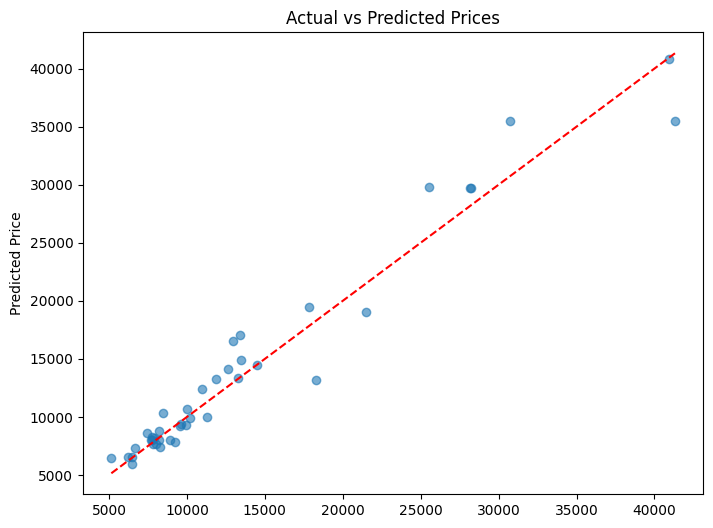

In [29]:
res_comp = test_score(X_test, y_test, "Random Forest", best_rf)[1]

plt.figure(figsize=(8,6))
plt.scatter(res_comp['Actual'], res_comp['Prediction'], alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()